# GenCast 20-member ensemble vs. observed week-2 PDF for 6 out-of-sample extreme events

**Question.** Initialized **14 days before** each event's peak, can the model's forecast
*distribution* at lead day 14 capture the observed (ERA5) extreme?

**Why GenCast, not GraphCast.** GraphCast is *deterministic* — repeated runs from identical initial
conditions give identical trajectories (a degenerate PDF). A real ensemble needs
**GenCast**, a diffusion model whose members are independent samples drawn with different RNG seeds.
We run GenCast (20 members) as the forecast and a single deterministic **GraphCast** run as a control.

**Setup.**
- Checkpoints: `GenCast 0p25deg <2019` and the 0.25°/37-level GraphCast (native WeatherBench-2 grid,
  no regridding). The `<2019` cutoff is why we restrict to the **6 out-of-sample (post-2019)** events.
- Init time = `peak − 14 days`; verify at the **week-2 window** (forecast days 8–14) using the
  weekly-mean **2 m-temperature anomaly** over CONUS.
- **PDF basis:** truth = anomaly across all CONUS grid points (one ERA5 realization); GenCast forecast
  = same anomaly pooled across 20 members × CONUS grid points; GraphCast = its single field.
- **Scoring (Cell G):** ensemble **CRPS** + **rank histograms** (GraphCast single-member CRPS = MAE).
- **Caching:** model **inputs** are built on demand per (event, model) and **not** cached — they are
  cheap to re-pull from GCS. Only the small, expensive **outputs** (predictions, truth, figures)
  persist to Google Drive so you can "run once, analyze later". The full 14-day rollout is streamed
  and discarded — only the week-2 product is kept. Set `USE_DRIVE = False` in Cell 0 to keep outputs
  local for maximum speed. Re-running skips cached outputs.

> Run order: **Cell 0 → A → B → C → D → E → F → G.** Cells B/C/E are resumable.


## Cell 0 — Colab environment + Google Drive

In [12]:
# --- Where to store things ---------------------------------------------------
# Bulky model INPUTS (~12 GB / run) live on fast local disk (/content): they re-pull
# from GCS in minutes, are too big for a 15 GB Drive, and Drive's FUSE mount is slow
# for large files. Only the small, expensive OUTPUTS (predictions ~0.5 GB, truth,
# figures) go to Drive so you can "run once, analyze later".
#
# USE_DRIVE = True  -> outputs persisted to Drive (resumable across sessions)
# USE_DRIVE = False -> everything local /content (fastest; lost when the VM recycles)
import os
USE_DRIVE = True

if USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        OUT = "/content/drive/MyDrive/gencast_extreme_events"     # persistent outputs
    except Exception as e:
        print("Drive mount failed -> falling back to local:", e)
        OUT = os.path.abspath("./gencast_extreme_events_out")
else:
    OUT = os.path.abspath("/content/gencast_extreme_events_out")

for d in [f"{OUT}/verif_truth", f"{OUT}/predictions", f"{OUT}/figures"]:
    os.makedirs(d, exist_ok=True)
print("OUT (Drive/outputs) =", OUT)
# Model inputs are built on demand in Cell E and never cached; only predictions are saved.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OUT (Drive/outputs) = /content/drive/MyDrive/gencast_extreme_events


In [13]:
# --- Install deps + clone graphcast (only needed once per Colab VM) ---
# NOTE: if pip changes jax/jaxlib, you may need Runtime > Restart, then re-run from Cell 0.
import importlib.util, subprocess, sys

def sh(cmd):
    print("$", cmd); subprocess.run(cmd, shell=True, check=False)

sh("pip install -q -U gcsfs zarr 'xarray>=2023.6' dask netCDF4 cdsapi properscoring")
if not os.path.isdir("graphcast"):
    sh("git clone https://github.com/google-deepmind/graphcast.git")
sh("pip install -q -e ./graphcast")  # pulls jax, dm-haiku, jraph, etc.

# Patch graphcast for newer xarray: `xarray.Dataset(ds)` (copy-construct from a Dataset)
# was removed and now raises TypeError. Rewrite the three rollout copies to `ds.copy()`.
# Idempotent: after the first rewrite the original pattern is gone, so re-runs are no-ops.
_rp = "graphcast/graphcast/rollout.py"
if os.path.exists(_rp):
    _src = open(_rp).read()
    for _v in ("inputs", "targets_template", "forcings"):
        _src = _src.replace(f"{_v} = xarray.Dataset({_v})", f"{_v} = {_v}.copy()")
    open(_rp, "w").write(_src)
    print("patched", _rp, "for xarray Dataset-copy compatibility")

$ pip install -q -U gcsfs zarr 'xarray>=2023.6' dask netCDF4 cdsapi properscoring
$ pip install -q -e ./graphcast
patched graphcast/graphcast/rollout.py for xarray Dataset-copy compatibility


In [14]:
# --- Imports + GPU check ---
import functools, dataclasses, datetime, math, warnings, os
# Set BEFORE importing jax: disable the default 75% GPU pre-grab so memory grows on demand
# (avoids OOM-killing the kernel on the heavy GenCast rollout), and allow up to 95% if needed.
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", ".95")
import numpy as np, pandas as pd, xarray as xr
import jax, haiku as hk
import matplotlib.pyplot as plt

from graphcast import (checkpoint, data_utils, rollout, normalization,
                       xarray_jax, xarray_tree)
from graphcast import gencast, nan_cleaning
from graphcast import graphcast as graphcast_lib, casting, autoregressive

warnings.filterwarnings("ignore", category=FutureWarning)
print("JAX devices:", jax.devices())
assert any("gpu" in d.platform.lower() or d.platform == "gpu" or "cuda" in str(d).lower()
           for d in jax.devices()), "No GPU visible — set Runtime > Change runtime type > GPU (H100)."


JAX devices: [CudaDevice(id=0)]


## Cell A — Config (per-model settings, the 6 out-of-sample events)

In [15]:
# Master list (peak_date, is_out_of_sample_post_2019). We run only the True ones.
ALL_EVENTS = {
    # Heat
    "PNW_HeatDome_2021":        ("2021-06-28", True),
    "Chicago_HeatWave_1995":    ("1995-07-14", False),
    "NAmerica_HeatWave_2012":   ("2012-07-04", False),
    "SCentral_HeatWave_2011":   ("2011-07-20", False),
    "SCentral_HeatDome_2023":   ("2023-06-27", False),
    "Southwest_HeatWave_2020":  ("2020-08-16", True),   # CA/Death Valley record (WB2 ERA5)
    "California_HeatWave_2022":  ("2022-09-06", True),  # record Sept West-coast heat (WB2 ERA5)
    # Cold
    "WinterStorm_Uri_2021":     ("2021-02-15", True),
    "PolarVortex_2019":         ("2019-01-30", True),
    "PolarVortex_2014":         ("2014-01-06", False),
    "WinterStorm_Elliott_2022": ("2022-12-23", True),
}
EVENTS = {k: v for k, v in ALL_EVENTS.items() if v[1]}   # 6 out-of-sample events
print("Running events:", list(EVENTS))

# gencast = ensemble (primary); graphcast = deterministic control.
# Default to GenCast-only so the first pass actually finishes on one GPU; add "graphcast"
# back once you have GenCast PDFs (it pulls 37 levels, ~6x more I/O, and is heavier).
MODELS = ["gencast"]
LEAD_DAYS = 14
N_MEMBERS = 20  # ensemble size (paper uses ~8/20; 20 is heavier but well-sampled)

# Pressure-level sets
P37 = (1,2,3,5,7,10,20,30,50,70,100,125,150,175,200,225,250,300,350,400,450,500,
       550,600,650,700,750,775,800,825,850,875,900,925,950,975,1000)
P13 = (50,100,150,200,250,300,400,500,600,700,850,925,1000)

ATM = ["temperature","geopotential","u_component_of_wind",
       "v_component_of_wind","vertical_velocity","specific_humidity"]

# CONUS box (lon in 0..360: -125 -> 235, -66 -> 294)
LAT = slice(24, 50); LON = slice(235, 294)

PARAMS_DIR_GC  = "gs://dm_graphcast/gencast/params/"
STATS_DIR_GC   = "gs://dm_graphcast/gencast/stats/"
PARAMS_DIR_GFC = "gs://dm_graphcast/params/"
STATS_DIR_GFC  = "gs://dm_graphcast/stats/"

# 1.0° "Mini" GenCast: the lightweight checkpoint that actually finishes on a single
# GPU. Swap to "GenCast 0p25deg <2019.npz" (and set res=0.25 in model_cfg) for full res.
GENCAST_PARAMS  = "GenCast 1p0deg Mini <2019.npz"
GRAPHCAST_PARAMS = ("GraphCast - ERA5 1979-2017 - resolution 0.25 - "
                    "pressure levels 37 - mesh 2to6 - precipitation input and output.npz")

def model_cfg(model):
    if model == "gencast":
        return dict(step_h=12, levels=13, levels_hpa=list(P13), res=1.0,
                    surf=["2m_temperature","mean_sea_level_pressure",
                          "10m_u_component_of_wind","10m_v_component_of_wind",
                          "sea_surface_temperature"],
                    precip_in="total_precipitation_12hr", n_members=N_MEMBERS,
                    params_dir=PARAMS_DIR_GC, params_file=GENCAST_PARAMS)
    elif model == "graphcast":
        return dict(step_h=6, levels=37, levels_hpa=list(P37), res=0.25,
                    surf=["2m_temperature","mean_sea_level_pressure",
                          "10m_u_component_of_wind","10m_v_component_of_wind"],
                    precip_in="total_precipitation_6hr", n_members=1,
                    params_dir=PARAMS_DIR_GFC, params_file=GRAPHCAST_PARAMS)
    raise ValueError(model)

def n_steps(model):  # rollout steps to reach lead day 14
    return LEAD_DAYS * 24 // model_cfg(model)["step_h"]

print({m: n_steps(m) for m in MODELS})

Running events: ['PNW_HeatDome_2021', 'Southwest_HeatWave_2020', 'California_HeatWave_2022', 'WinterStorm_Uri_2021', 'PolarVortex_2019', 'WinterStorm_Elliott_2022']
{'gencast': 28}


## Cell B — Define init-frame builder (peak − 14 d), built on demand

`build_inputs(model, peak)` returns the two real input frames `STEP_H` apart on the native WB2 grid.
Inputs are **not** cached — Cell E calls this directly per (event, model) and only the predictions are saved.

In [16]:
# WeatherBench-2 ERA5 stores cover 1959-01-01 .. 2023-01-10 18:00 ONLY.
# Events after that (init date past WB2_END) fall back to ARCO-ERA5,
# the continuously-updated 0.25deg/37-level superset GraphCast was trained on.
SURF_STORE   = "gs://weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr"
FULL37_STORE = "gs://weatherbench2/datasets/era5/1959-2023_01_10-full_37-1h-0p25deg-chunk-1.zarr"
ARCO_STORE   = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"
WB2_END      = pd.Timestamp("2023-01-10T18:00:00")

def open_anon(url):
    ds = xr.open_zarr(url, storage_options={"token": "anon"}, chunks={"time": 1})
    if "latitude" in ds.coords:  ds = ds.rename({"latitude": "lat", "longitude": "lon"})
    if float(ds.lat[0]) > float(ds.lat[-1]):       # stores are 90->-90; models want -90->90
        ds = ds.isel(lat=slice(None, None, -1))
    return ds

_surf_src = open_anon(SURF_STORE)
_atm37_src = None   # WB2 37-level store, opened lazily (graphcast within WB2 coverage)
_arco_src  = None   # ARCO-ERA5, opened lazily (any time past WB2 coverage)
def _atm37():
    global _atm37_src
    if _atm37_src is None: _atm37_src = open_anon(FULL37_STORE)
    return _atm37_src
def _arco():
    global _arco_src
    if _arco_src is None: _arco_src = open_anon(ARCO_STORE)
    return _arco_src
def past_wb2(times):
    return pd.DatetimeIndex(np.atleast_1d(times)).max() > WB2_END

def get_statics():
    have = {"geopotential_at_surface", "land_sea_mask"} <= set(_surf_src.data_vars)
    if have:
        s = _surf_src[["geopotential_at_surface", "land_sea_mask"]]
        return {v: (s[v].isel(time=0, drop=True) if "time" in s[v].dims else s[v])
                for v in s.data_vars}
    import cdsapi, getpass
    cdsapi.Client(url="https://cds.climate.copernicus.eu/api",
                  key=getpass.getpass("CDS token (orography + land-sea mask): ")).retrieve(
        "reanalysis-era5-single-levels",
        {"product_type": ["reanalysis"], "variable": ["geopotential", "land_sea_mask"],
         "year": ["2021"], "month": ["01"], "day": ["01"], "time": ["00:00"],
         "data_format": "netcdf", "download_format": "unarchived"}, "static.nc")
    st = xr.open_dataset("static.nc").rename({"latitude": "lat", "longitude": "lon"})
    if float(st.lat[0]) > float(st.lat[-1]): st = st.isel(lat=slice(None, None, -1))
    st = st.isel(valid_time=0, drop=True) if "valid_time" in st.dims else st.squeeze()
    return {"geopotential_at_surface": st["z"], "land_sea_mask": st["lsm"]}

STATICS = get_statics()

def _precip_accum(src, times, win_h, out_name):
    # Build the `win_h`-hour precip accumulation ending at each frame time. Prefer the store's
    # own 6-hour accumulation (sum consecutive blocks) and fall back to hourly 'total_precipitation'
    # (ARCO). GraphCast wants 6h, GenCast wants 12h.
    times = pd.DatetimeIndex(times)
    if "total_precipitation_6hr" in src and win_h % 6 == 0:
        var, step = "total_precipitation_6hr", 6
    elif "total_precipitation" in src:
        var, step = "total_precipitation", 1
    else:
        raise KeyError(f"no precipitation source in store to build {out_name}")
    frames = [src[var].sel(
                  time=pd.date_range(t - pd.Timedelta(hours=win_h - step), t, freq=f"{step}h")
              ).sum("time") for t in times]
    return xr.concat(frames, dim="time").assign_coords(
        time=list(times)).to_dataset(name=out_name)

def build_inputs(model, peak, verbose=False):
    cfg = model_cfg(model); step_h = cfg["step_h"]
    init  = pd.Timestamp(peak) - pd.Timedelta(days=14)
    times = pd.to_datetime([init - pd.Timedelta(hours=step_h), init])  # 2 input frames
    if past_wb2(times):                       # June-2023 etc. -> ARCO-ERA5 (surf+atm in one store)
        surf_src = atm_src = _arco()
        if verbose: print("   (using ARCO-ERA5: past WB2 coverage)")
    else:
        surf_src = _surf_src
        atm_src  = _atm37() if cfg["levels"] == 37 else _surf_src
    sv      = [v for v in cfg["surf"] if v in surf_src]
    missing = [v for v in cfg["surf"] if v not in surf_src]
    if missing and verbose:
        print("   ! surface vars missing in store:", missing, "-> need CDS or another store")
    parts = [atm_src[ATM].sel(time=times, level=cfg["levels_hpa"]),
             surf_src[sv].sel(time=times)]
    if cfg["precip_in"]:
        pname = cfg["precip_in"]
        win_h = int(pname.rsplit("_", 1)[1].removesuffix("hr"))   # ..._6hr -> 6, ..._12hr -> 12
        if pname in surf_src:
            parts.append(surf_src[[pname]].sel(time=times))
        else:
            # Derive the accumulation. Prefer the active store's 6hr/hourly precip; if it has
            # neither, fall back to ARCO hourly 'total_precipitation' (covers all dates).
            psrc = (surf_src if ("total_precipitation_6hr" in surf_src
                                 or "total_precipitation" in surf_src) else _arco())
            if verbose and psrc is not surf_src:
                print(f"   (precip {pname}: store lacks it -> deriving from ARCO hourly)")
            parts.append(_precip_accum(psrc, times, win_h, pname))
    ds = xr.merge(parts).expand_dims(batch=1)
    # Coarsen the GLOBAL field to the model's native grid (GenCast Mini = 1.0deg, from the
    # 0.25deg ERA5 stores; stride 4 -> 181x360). GenCast is a global model: keep the whole
    # globe here and only subset to CONUS *after* prediction.
    stride = int(round(cfg["res"] / 0.25))
    sub = (lambda a: a.isel(lat=slice(None, None, stride), lon=slice(None, None, stride))) \
          if stride > 1 else (lambda a: a)
    ds = sub(ds)
    t = ds["time"].values
    ds = ds.assign_coords(datetime=(("batch", "time"), t[None, :]),
                          time=("time", t - t[-1]))         # last input frame -> lead 0
    for k, v in STATICS.items():
        ds[k] = sub(v)
    return ds.compute()

# Sanity check only: build (don't cache) the first event/model so failures surface here.
_first = list(EVENTS)[0]
print(build_inputs(MODELS[0], EVENTS[_first][0], verbose=True))

<xarray.Dataset> Size: 44MB
Dimensions:                   (batch: 1, time: 2, level: 13, lat: 181, lon: 360)
Coordinates:
  * time                      (time) timedelta64[ns] 16B -1 days +12:00:00 00...
    datetime                  (batch, time) datetime64[ns] 16B 2021-06-13T12:...
  * level                     (level) int64 104B 50 100 150 200 ... 850 925 1000
  * lat                       (lat) float32 724B -90.0 -89.0 -88.0 ... 89.0 90.0
  * lon                       (lon) float32 1kB 0.0 1.0 2.0 ... 358.0 359.0
Dimensions without coordinates: batch
Data variables: (12/14)
    temperature               (batch, time, level, lat, lon) float32 7MB 187....
    geopotential              (batch, time, level, lat, lon) float32 7MB 1.81...
    u_component_of_wind       (batch, time, level, lat, lon) float32 7MB 0.00...
    v_component_of_wind       (batch, time, level, lat, lon) float32 7MB 0.00...
    vertical_velocity         (batch, time, level, lat, lon) float32 7MB -0.0...
    specifi

## Cell C — Verification truth: observed week-2 weekly-mean T2m anomaly over CONUS

In [17]:
CLIM_STORE = "gs://weatherbench2/datasets/era5-hourly-climatology/1990-2019_6h_1440x721.zarr"
CLIM = open_anon(CLIM_STORE)["2m_temperature"]   # dims (hour, dayofyear, lat, lon)

def clim_for(times):
    t = pd.DatetimeIndex(times)
    # np.asarray: t.hour/.dayofyear are pandas Index objects; passing them straight to
    # xr.DataArray would attach them as a 'time' coordinate and make the two indexers
    # collide on merge inside .sel. Plain arrays index pointwise with no coord.
    return CLIM.sel(hour=xr.DataArray(np.asarray(t.hour), dims="time"),
                    dayofyear=xr.DataArray(np.asarray(t.dayofyear), dims="time"))

def true_week2_anom(peak):
    peak = pd.Timestamp(peak)
    win  = pd.date_range(peak - pd.Timedelta(days=6), peak, freq="6h")  # forecast days 8-14
    src  = _arco() if past_wb2(win) else _surf_src                      # ARCO past WB2 coverage
    obs  = src["2m_temperature"].sel(time=win)
    anom = obs.mean("time") - clim_for(win).mean("time")               # clim is 1990-2019, always WB2
    return anom.sel(lat=LAT, lon=LON).compute()                        # (lat, lon)

for name, (peak, _) in EVENTS.items():
    f = f"{OUT}/verif_truth/{name}_true_week2_t2m_anom.nc"
    if os.path.exists(f):
        print("  cached:", os.path.basename(f)); continue
    da = true_week2_anom(peak)
    da.to_dataset(name="t2m_anom").to_netcdf(f)
    print(f"truth saved: {name}  mean={float(da.mean()):+.2f}K  max={float(da.max()):+.2f}K")

  cached: PNW_HeatDome_2021_true_week2_t2m_anom.nc
  cached: Southwest_HeatWave_2020_true_week2_t2m_anom.nc
  cached: California_HeatWave_2022_true_week2_t2m_anom.nc
  cached: WinterStorm_Uri_2021_true_week2_t2m_anom.nc
  cached: PolarVortex_2019_true_week2_t2m_anom.nc
  cached: WinterStorm_Elliott_2022_true_week2_t2m_anom.nc


## Cell D — Load model params/stats and build the forward functions

GenCast wrapping = `GenCast → InputsAndResiduals → NaNCleaner(sea_surface_temperature)`, pmapped over
the ensemble. GraphCast wrapping = `GraphCast → Bfloat16Cast → InputsAndResiduals → autoregressive`.

In [18]:
import gcsfs
_gcs = gcsfs.GCSFileSystem(token="anon")

def _load_stats(stats_dir):
    out = {}
    for nm in ["diffs_stddev_by_level", "mean_by_level", "stddev_by_level", "min_by_level"]:
        path = stats_dir + nm + ".nc"
        if not _gcs.exists(path):  # min_by_level only ships with gencast
            continue
        with _gcs.open(path, "rb") as fobj:
            out[nm] = xr.load_dataset(fobj).compute()
    return out

def _with_params(fn, params, state):
    # Bind params/state positionally (apply signature: params, state, rng, inputs, ...).
    # xarray_jax.pmap calls the wrapped fn with positional args, so we must not pin these
    # as keywords or the pmap (GenCast) path passes rng/inputs/... positionally and clashes.
    return functools.partial(fn, params, state)
def _drop_state(fn):
    # Accept both positional (pmap/GenCast) and keyword (GraphCast) call styles.
    return lambda *a, **kw: fn(*a, **kw)[0]

LOADED = {}   # model -> dict(forward=..., task_config=..., n_members=...)

# ---------- GenCast ----------
if "gencast" in MODELS:
    cfg = model_cfg("gencast")
    with _gcs.open(cfg["params_dir"] + cfg["params_file"], "rb") as fobj:
        ckpt = checkpoint.load(fobj, gencast.CheckPoint)
    gc_params, gc_state = ckpt.params, {}
    gc_task = ckpt.task_config
    st = _load_stats(cfg["params_dir"].replace("params/", "stats/"))

    # The checkpoint was trained on TPU with "splash_mha" attention — a Pallas kernel that
    # fails on GPU ("scalar prefetch not implemented in the Triton backend"). Swap it for the
    # GPU-compatible dense attention before building the predictor.
    gc_darch = dataclasses.replace(
        ckpt.denoiser_architecture_config,
        sparse_transformer_config=dataclasses.replace(
            ckpt.denoiser_architecture_config.sparse_transformer_config,
            attention_type="triblockdiag_mha", mask_type="full"))

    def _wrap_gencast():
        p = gencast.GenCast(sampler_config=ckpt.sampler_config,
                            task_config=ckpt.task_config,
                            denoiser_architecture_config=gc_darch,
                            noise_config=ckpt.noise_config,
                            noise_encoder_config=ckpt.noise_encoder_config)
        p = normalization.InputsAndResiduals(
                p, diffs_stddev_by_level=st["diffs_stddev_by_level"],
                mean_by_level=st["mean_by_level"], stddev_by_level=st["stddev_by_level"])
        p = nan_cleaning.NaNCleaner(predictor=p, reintroduce_nans=True,
                                    fill_value=st["min_by_level"],
                                    var_to_clean="sea_surface_temperature")
        return p

    @hk.transform_with_state
    def _gc_forward(inputs, targets_template, forcings):
        return _wrap_gencast()(inputs, targets_template=targets_template, forcings=forcings)

    gc_jit  = _drop_state(_with_params(jax.jit(_gc_forward.apply), gc_params, gc_state))
    gc_pmap = xarray_jax.pmap(gc_jit, dim="sample")
    LOADED["gencast"] = dict(forward=gc_pmap, task_config=gc_task,
                             n_members=cfg["n_members"], ensemble=True)
    print("GenCast loaded. task pressure levels:", gc_task.pressure_levels[:3], "...")

# ---------- GraphCast (deterministic control) ----------
if "graphcast" in MODELS:
    cfg = model_cfg("graphcast")
    with _gcs.open(cfg["params_dir"] + cfg["params_file"], "rb") as fobj:
        ckpt2 = checkpoint.load(fobj, graphcast_lib.CheckPoint)
    gfc_params, gfc_state = ckpt2.params, {}
    gfc_task, gfc_model = ckpt2.task_config, ckpt2.model_config
    st2 = _load_stats(STATS_DIR_GFC)

    def _wrap_graphcast():
        p = graphcast_lib.GraphCast(gfc_model, gfc_task)
        p = casting.Bfloat16Cast(p)
        p = normalization.InputsAndResiduals(
                p, diffs_stddev_by_level=st2["diffs_stddev_by_level"],
                mean_by_level=st2["mean_by_level"], stddev_by_level=st2["stddev_by_level"])
        p = autoregressive.Predictor(p, gradient_checkpointing=True)
        return p

    @hk.transform_with_state
    def _gfc_forward(inputs, targets_template, forcings):
        return _wrap_graphcast()(inputs, targets_template=targets_template, forcings=forcings)

    gfc_jit = _drop_state(_with_params(jax.jit(_gfc_forward.apply), gfc_params, gfc_state))
    LOADED["graphcast"] = dict(forward=gfc_jit, task_config=gfc_task,
                               n_members=1, ensemble=False)
    print("GraphCast loaded. task pressure levels:", len(gfc_task.pressure_levels))

GenCast loaded. task pressure levels: (50, 100, 150) ...


## Cell E — Inference per (event, model); stream rollout, keep only week-2, cache

Builds the example batch (2 real input frames + NaN target placeholders), runs the rollout, and keeps
**only** the week-2 (lead days 8–14) 2 m-temperature frames — the full 14-day trajectory is discarded.
Output cached as the per-member week-2 anomaly field `(member, lat, lon)`.

In [19]:
WEEK2_START = np.timedelta64(LEAD_DAYS - 6, "D")   # lead day 8 (= init + 8d)

def build_example_batch(model, name, peak):
    cfg = model_cfg(model); step_h = cfg["step_h"]
    init = pd.Timestamp(peak) - pd.Timedelta(days=14)
    ds = build_inputs(model, peak)   # built on demand, not cached
    # full datetime axis: 2 real input frames + N NaN target placeholder frames
    in_dt = pd.DatetimeIndex(ds["datetime"].values.ravel())
    future = pd.date_range(init + pd.Timedelta(hours=step_h), peak, freq=f"{step_h}h")
    all_dt = pd.DatetimeIndex(in_dt.append(future))
    all_td = (all_dt.values - np.datetime64(init)).astype("timedelta64[ns]")  # rel. to last input
    # NaN target template by repeating the last input frame N times, then blanking time-varying vars
    tmpl = ds.isel(time=[ds.sizes["time"] - 1] * len(future))
    for v in tmpl.data_vars:
        if "time" in tmpl[v].dims:
            tmpl[v] = tmpl[v] * np.nan
    # data_vars/coords="minimal": do NOT broadcast time-independent statics
    # (geopotential_at_surface, land_sea_mask) onto the time axis — otherwise each gains a
    # spurious time dim and adds an extra input feature, breaking the encoder weight shapes.
    full = xr.concat([ds, tmpl], dim="time",
                     data_vars="minimal", coords="minimal", compat="override")
    full = full.assign_coords(time=("time", all_td),
                              datetime=(("batch", "time"), all_dt.values[None, :]))
    # Statics MUST stay 2-D (lat, lon). If the concat above let a `time` axis leak onto them,
    # each static becomes 2 input channels instead of 1 -> the encoder sees 269 features when
    # the GenCast checkpoint expects 267. Strip any stray time axis to guarantee 1 channel each.
    for k in ("geopotential_at_surface", "land_sea_mask"):
        if k in full.data_vars and "time" in full[k].dims:
            full[k] = full[k].isel(time=0, drop=True)
    return full, init

def to_week2_anom(t2m, init):
    # t2m: (..., time, lat, lon) with timedelta 'time'; -> week-2 mean anomaly over CONUS
    valid = pd.DatetimeIndex(np.datetime64(init) + t2m["time"].values)
    clim_mean = clim_for(valid).mean("time")
    anom = t2m.mean("time") - clim_mean
    return anom.sel(lat=LAT, lon=LON)

def run_event_model(model, name, peak):
    cfg = model_cfg(model)
    out_f = f"{OUT}/predictions/{name}_{model}_week2_t2m_anom_members.nc"
    if os.path.exists(out_f):
        # Member-aware cache: a file saved with a different ensemble size (e.g. an
        # earlier 4-member run) must NOT be reused after bumping N_MEMBERS, or the
        # PDFs/CRPS/rank-histograms mix member counts. Re-run on mismatch.
        want = LOADED[model]["n_members"]
        try:
            have = int(xr.open_dataset(out_f).sizes.get("member", 1))
        except Exception:
            have = None
        if have == want:
            print(f"  cached: {os.path.basename(out_f)} ({have} members)"); return out_f
        print(f"  stale cache ({have} members != requested {want}) -> re-running")

    full, init = build_example_batch(model, name, peak)
    task = LOADED[model]["task_config"]
    eval_inputs, eval_targets, eval_forcings = data_utils.extract_inputs_targets_forcings(
        full, target_lead_times=slice(f"{cfg['step_h']}h", f"{LEAD_DAYS*24}h"),
        **dataclasses.asdict(task))

    # Cheap pre-flight (no GPU): count grid-node input channels the model will build.
    # GenCast expects 267; +2 almost always means a static var leaked a `time` axis.
    def _nch(d):
        return int(sum(np.prod([d[v].sizes[x] for x in d[v].dims if x not in ("lat", "lon")] or [1])
                       for v in d.data_vars))
    feat = _nch(eval_inputs) + _nch(eval_targets) + _nch(eval_forcings)
    print(f"  grid-node input channels = {feat}  "
          f"(inputs {_nch(eval_inputs)} + targets {_nch(eval_targets)} + forcings {_nch(eval_forcings)})")

    kept = []   # week-2 2m_temperature frames only
    if LOADED[model]["ensemble"]:
        nm = LOADED[model]["n_members"]
        rng = jax.random.PRNGKey(0)
        rngs = np.stack([jax.random.fold_in(rng, i) for i in range(nm)], axis=0)
        gen = rollout.chunked_prediction_generator_multiple_runs(
            predictor_fn=LOADED[model]["forward"], rngs=rngs,
            inputs=eval_inputs, targets_template=eval_targets * np.nan,
            forcings=eval_forcings, num_steps_per_chunk=1,
            num_samples=nm, pmap_devices=jax.local_devices())
    else:
        gen = rollout.chunked_prediction_generator(
            predictor_fn=LOADED[model]["forward"], rng=jax.random.PRNGKey(0),
            inputs=eval_inputs, targets_template=eval_targets * np.nan,
            forcings=eval_forcings, num_steps_per_chunk=1)

    for chunk in gen:
        t2m = chunk["2m_temperature"]
        mask = chunk["time"].values >= WEEK2_START
        if mask.any():
            # Slice to the CONUS box *before* pulling to host RAM: we only ever use this
            # region (to_week2_anom subsets to LAT/LON anyway), so keeping the global field
            # for every step x member balloons host memory ~40x and can OOM-kill the kernel.
            kept.append(t2m.isel(time=np.where(mask)[0])
                           .sel(lat=LAT, lon=LON).compute())
        del chunk

    pred = xr.concat(kept, dim="time")
    if "sample" in pred.dims:
        pred = pred.rename({"sample": "member"})
    if "member" not in pred.dims:
        pred = pred.expand_dims(member=[0])
    anom = to_week2_anom(pred, init)
    if "batch" in anom.dims:                 # drop the leftover size-1 batch axis
        anom = anom.isel(batch=0, drop=True)
    anom = anom.transpose("member", "lat", "lon")
    anom.to_dataset(name="t2m_anom").to_netcdf(out_f)
    print(f"  saved {os.path.basename(out_f)}  members={anom.sizes['member']} "
          f"spread={float(anom.std('member').mean()):.3f}K")
    return out_f

for name, (peak, _) in EVENTS.items():
    for model in MODELS:
        print(f"{name} [{model}] ...")
        run_event_model(model, name, peak)

PNW_HeatDome_2021 [gencast] ...
  stale cache (4 members != requested 20) -> re-running
  grid-node input channels = 2640  (inputs 176 + targets 2352 + forcings 112)


/content/graphcast/graphcast/denoiser.py:298: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._mesh = _permute_mesh_to_banded(mesh=mesh)
/content/graphcast/graphcast/transformer.py:86: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  adj_mat=_get_adj_matrix_for_edge_set(


  saved PNW_HeatDome_2021_gencast_week2_t2m_anom_members.nc  members=20 spread=1.185K
Southwest_HeatWave_2020 [gencast] ...
  cached: Southwest_HeatWave_2020_gencast_week2_t2m_anom_members.nc (20 members)
California_HeatWave_2022 [gencast] ...
  cached: California_HeatWave_2022_gencast_week2_t2m_anom_members.nc (20 members)
WinterStorm_Uri_2021 [gencast] ...
  stale cache (4 members != requested 20) -> re-running
  grid-node input channels = 2640  (inputs 176 + targets 2352 + forcings 112)
  saved WinterStorm_Uri_2021_gencast_week2_t2m_anom_members.nc  members=20 spread=2.555K
PolarVortex_2019 [gencast] ...
  stale cache (4 members != requested 20) -> re-running
  grid-node input channels = 2640  (inputs 176 + targets 2352 + forcings 112)
  saved PolarVortex_2019_gencast_week2_t2m_anom_members.nc  members=20 spread=2.601K
WinterStorm_Elliott_2022 [gencast] ...
  stale cache (4 members != requested 20) -> re-running
  grid-node input channels = 2640  (inputs 176 + targets 2352 + forcing

## Cell F — PDF figure (log y-axis floored at e⁻⁵)

Per event: observed truth PDF, GenCast 20-member ensemble PDF (pooled members × grid points), and the
GraphCast deterministic control — all over CONUS grid points.

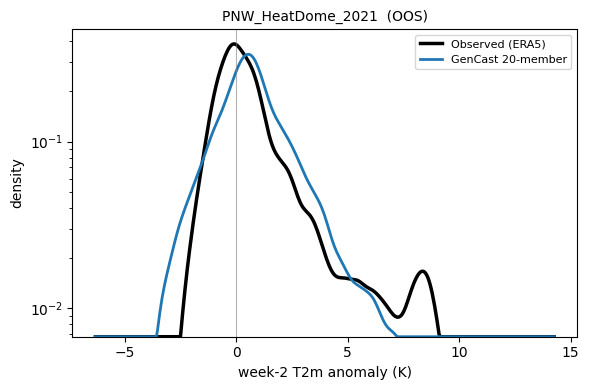

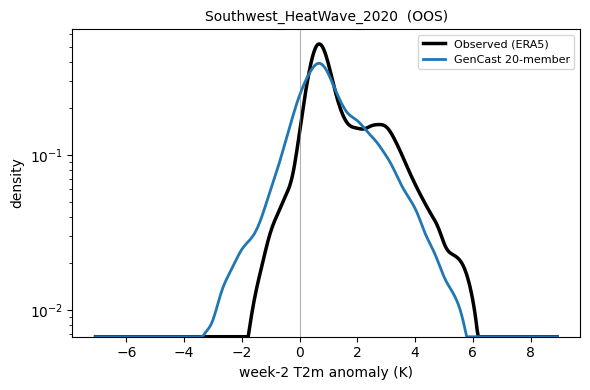

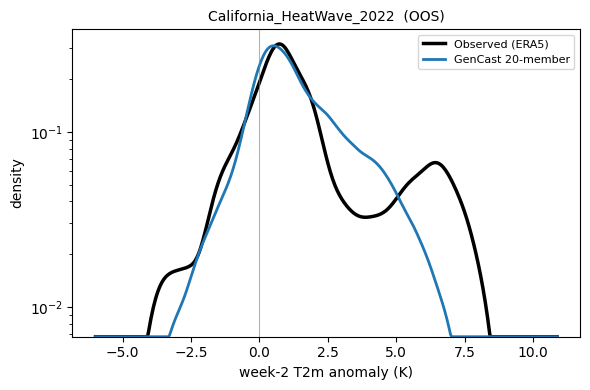

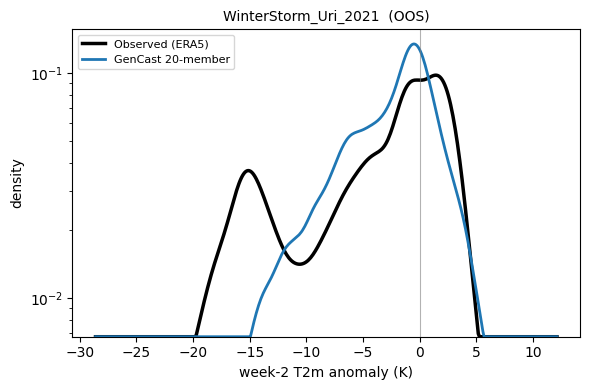

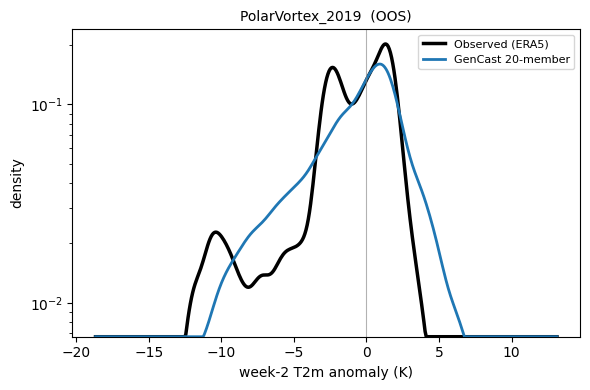

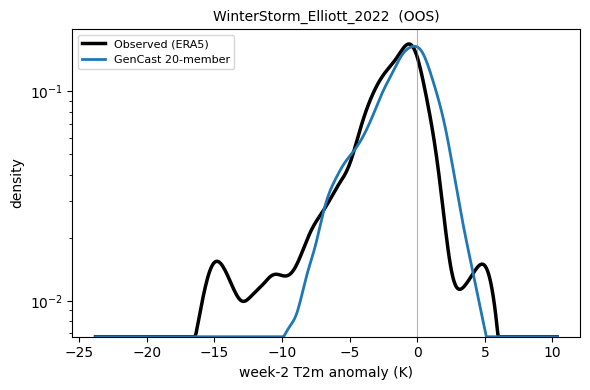

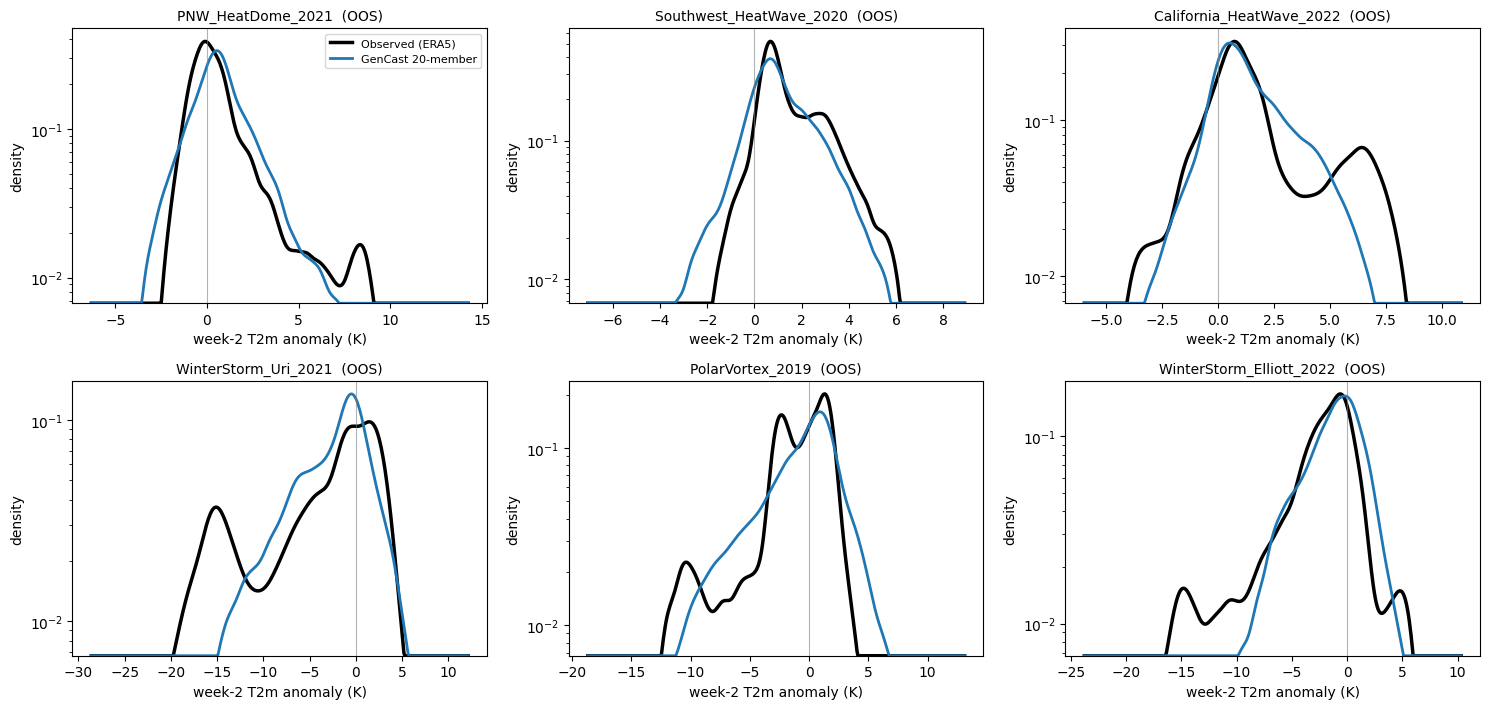

In [20]:
from scipy.stats import gaussian_kde

YMIN = math.exp(-5)   # floor for the log y-axis

def load_samples(name):
    truth = xr.open_dataset(f"{OUT}/verif_truth/{name}_true_week2_t2m_anom.nc")["t2m_anom"]
    out = {"truth": truth.values.ravel()}
    for model in MODELS:
        p = f"{OUT}/predictions/{name}_{model}_week2_t2m_anom_members.nc"
        if os.path.exists(p):
            out[model] = xr.open_dataset(p)["t2m_anom"].values.ravel()
    return out

def pdf_on_grid(sample, xgrid):
    sample = sample[np.isfinite(sample)]
    if sample.size < 5 or np.allclose(sample, sample[0]):
        # deterministic / degenerate -> narrow spike at the mean
        d = np.full_like(xgrid, YMIN); d[np.argmin(np.abs(xgrid - np.nanmean(sample)))] = 1.0
        return d
    return gaussian_kde(sample)(xgrid)

STYLE = {"truth": dict(color="k", lw=2.5, label="Observed (ERA5)"),
         "gencast": dict(color="tab:blue", lw=2.0,
                         label=f"GenCast {model_cfg('gencast')['n_members']}-member"),
         "graphcast": dict(color="tab:red", lw=1.8, ls="--", label="GraphCast control")}

def plot_event(ax, name, oos):
    s = load_samples(name)
    allv = np.concatenate([v[np.isfinite(v)] for v in s.values()])
    xgrid = np.linspace(allv.min() - 1, allv.max() + 1, 400)
    for key in ["truth", "gencast", "graphcast"]:
        if key not in s:  continue
        d = np.clip(pdf_on_grid(s[key], xgrid), YMIN, None)
        ax.plot(xgrid, d, **STYLE[key])
    ax.axvline(0, color="grey", lw=0.8, alpha=0.6)
    ax.set_yscale("log"); ax.set_ylim(YMIN, None)
    ax.set_title(f"{name}  ({'OOS' if oos else 'in-train'})", fontsize=10)
    ax.set_xlabel("week-2 T2m anomaly (K)"); ax.set_ylabel("density")

# one figure per event
for name, (_, oos) in EVENTS.items():
    fig, ax = plt.subplots(figsize=(6, 4))
    plot_event(ax, name, oos); ax.legend(fontsize=8)
    fig.tight_layout(); fig.savefig(f"{OUT}/figures/{name}_pdf.png", dpi=140)
    plt.show()

# combined grid
n = len(EVENTS); cols = 3; rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 3.6*rows), squeeze=False)
for ax, (name, (_, oos)) in zip(axes.ravel(), EVENTS.items()):
    plot_event(ax, name, oos)
axes.ravel()[0].legend(fontsize=8)
for ax in axes.ravel()[n:]: ax.axis("off")
fig.tight_layout(); fig.savefig(f"{OUT}/figures/all_events_pdf.png", dpi=140); plt.show()

## Cell G — CRPS + rank histograms (ensemble calibration)

Did the spread capture the extreme? CRPS scores the GenCast ensemble against the single ERA5 truth at
each CONUS grid point (GraphCast's single-member CRPS reduces to MAE). The rank histogram shows where
the observed value falls among the 20 sorted members: flat ⇒ calibrated, U-shape ⇒ under-dispersed
(spread too narrow — missed the extreme), dome ⇒ over-dispersed.

In [21]:
import properscoring as ps

def fields(name):
    truth = xr.open_dataset(f"{OUT}/verif_truth/{name}_true_week2_t2m_anom.nc")["t2m_anom"]
    out = {"truth": truth}
    for model in MODELS:
        p = f"{OUT}/predictions/{name}_{model}_week2_t2m_anom_members.nc"
        if os.path.exists(p):
            out[model] = xr.open_dataset(p)["t2m_anom"]
    return out

def _match(truth, fc):
    # Truth is saved on the ERA5 0.25 grid; forecasts may be coarser (GenCast Mini = 1.0).
    # Align truth onto the forecast's CONUS grid so the arrays score point-for-point.
    return truth.sel(lat=fc["lat"], lon=fc["lon"], method="nearest").values

rows = []; rankhists = {}
for name, (_, oos) in EVENTS.items():
    F = fields(name)
    truth = F["truth"]                                   # (lat, lon)
    rec = {"event": name, "oos": oos}
    if "gencast" in F:
        ensda = F["gencast"]                             # (member, lat, lon)
        obs = _match(truth, ensda)                       # aligned to forecast grid
        ens = ensda.values
        # CRPS per grid point (members along axis 0 -> move to last for properscoring)
        crps = ps.crps_ensemble(obs, np.moveaxis(ens, 0, -1))
        rec["gencast_crps"] = float(np.nanmean(crps))
        rec["gencast_spread"] = float(np.nanstd(ens, axis=0).mean())
        # rank histogram: rank of obs among members at each grid point
        below = (ens < obs[None]).sum(axis=0)            # 0..M
        nm = ens.shape[0]
        rankhists[name] = np.bincount(below.ravel(), minlength=nm + 1)
    if "graphcast" in F:
        ctrl = F["graphcast"].values[0]
        rec["graphcast_mae"] = float(np.nanmean(np.abs(ctrl - _match(truth, F["graphcast"]))))
    rows.append(rec)

scores = pd.DataFrame(rows)
scores.to_csv(f"{OUT}/predictions/scores.csv", index=False)
print(scores.to_string(index=False))

                   event  oos  gencast_crps  gencast_spread
       PNW_HeatDome_2021 True      0.619747        1.185266
 Southwest_HeatWave_2020 True      0.566357        1.107576
California_HeatWave_2022 True      0.911618        1.229045
    WinterStorm_Uri_2021 True      2.295280        2.555244
        PolarVortex_2019 True      0.935425        2.601305
WinterStorm_Elliott_2022 True      1.681078        2.336968


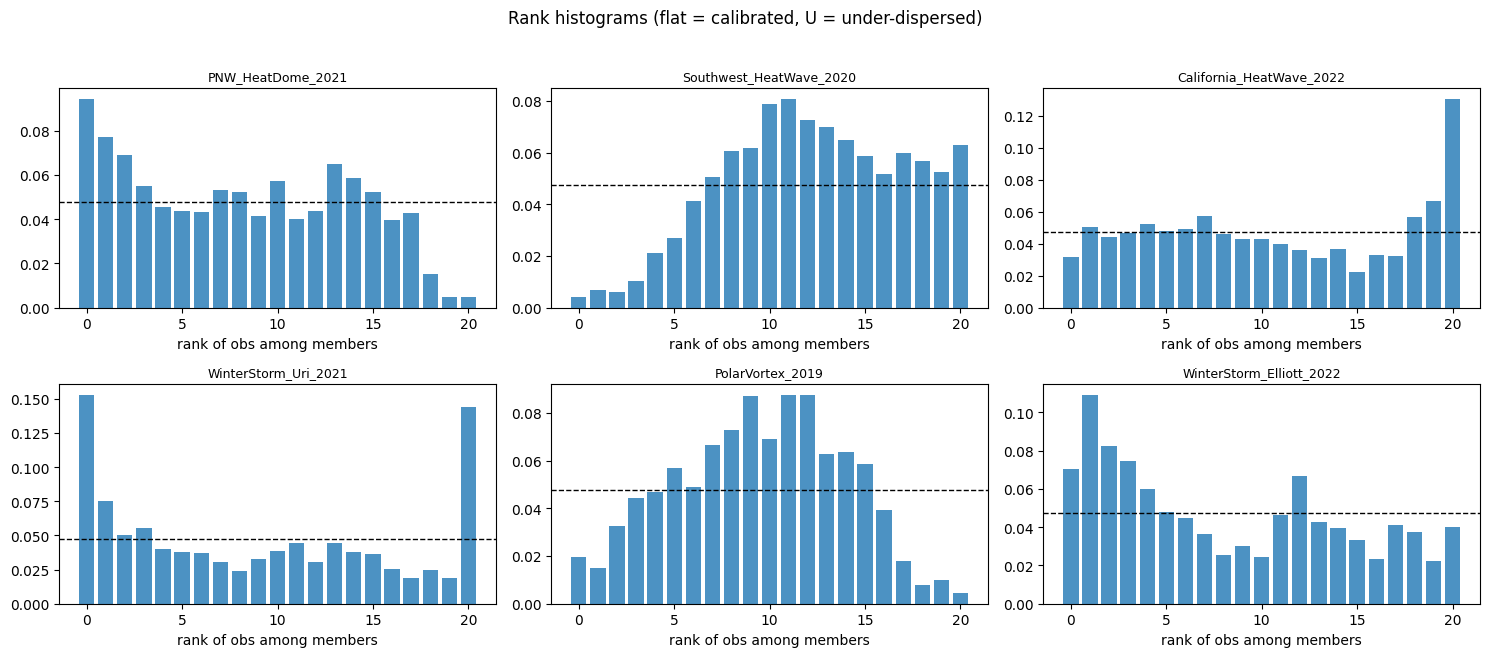

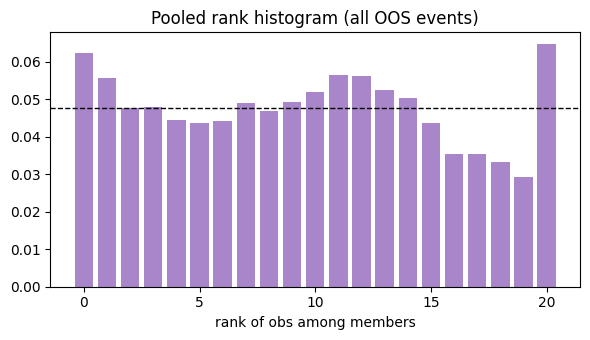

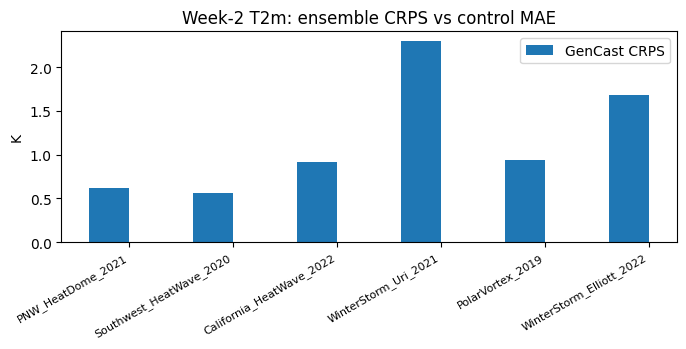

In [22]:
# Rank-histogram figures (per event + pooled) and a CRPS-vs-MAE summary bar
n = len(rankhists); cols = 3; rows_ = math.ceil(n / cols)
fig, axes = plt.subplots(rows_, cols, figsize=(5*cols, 3.2*rows_), squeeze=False)
pooled = None
for ax, (name, h) in zip(axes.ravel(), rankhists.items()):
    pooled = h.copy() if pooled is None else pooled + h
    ax.bar(np.arange(len(h)), h / h.sum(), color="tab:blue", alpha=0.8)
    ax.axhline(1/len(h), color="k", ls="--", lw=1)
    ax.set_title(name, fontsize=9); ax.set_xlabel("rank of obs among members")
for ax in axes.ravel()[n:]: ax.axis("off")
fig.suptitle("Rank histograms (flat = calibrated, U = under-dispersed)", y=1.02)
fig.tight_layout(); fig.savefig(f"{OUT}/figures/rank_histograms.png", dpi=140, bbox_inches="tight")
plt.show()

if pooled is not None:
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.bar(np.arange(len(pooled)), pooled / pooled.sum(), color="tab:purple", alpha=0.8)
    ax.axhline(1/len(pooled), color="k", ls="--", lw=1)
    ax.set_title("Pooled rank histogram (all OOS events)")
    ax.set_xlabel("rank of obs among members")
    fig.tight_layout(); fig.savefig(f"{OUT}/figures/rank_hist_pooled.png", dpi=140); plt.show()

# CRPS (ensemble) vs MAE (control)
if "gencast_crps" in scores:
    fig, ax = plt.subplots(figsize=(7, 3.6)); x = np.arange(len(scores)); w = 0.38
    ax.bar(x - w/2, scores["gencast_crps"], w, label="GenCast CRPS", color="tab:blue")
    if "graphcast_mae" in scores:
        ax.bar(x + w/2, scores["graphcast_mae"], w, label="GraphCast MAE", color="tab:red")
    ax.set_xticks(x); ax.set_xticklabels(scores["event"], rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("K"); ax.legend(); ax.set_title("Week-2 T2m: ensemble CRPS vs control MAE")
    fig.tight_layout(); fig.savefig(f"{OUT}/figures/crps_summary.png", dpi=140, bbox_inches="tight")
    plt.show()

## Caveats

- The "true PDF" is a single ERA5 realization → per grid point it is a point value; the PDF figure
  compares the *spatial* distribution over CONUS, while CRPS + rank histograms (Cell G) give the
  standard pointwise ensemble-calibration scoring of spread vs. the observed extreme.
- Only the 6 out-of-sample (post-2019) events are run; pre-2019 events fall in the checkpoints'
  training period (apparent skill there could be memorization).
- 0.25° GenCast is memory/time heavy on a single H100: 20 members × 28 diffusion rollouts × 6 events.
  Per-(event, model) Drive caching of predictions makes the run resumable — re-running skips finished work.
